# CASE 3: 1D Heat Diffusion Equation with Mixed Boundary Conditions (No Source Term)

## Governing Equation

∂y/∂t = ∂²y/∂x²

## Boundary Conditions

Left Boundary (Dirichlet)

y(0) = 1

Right Boundary (Neumann)

dy/dx (1) = 0

## Initial Condition

y(x,0) = sin(πx)

## Objective

To study the transient and steady-state behaviour of the one-dimensional heat diffusion equation under mixed boundary conditions using the finite volume method implemented in FiPy.

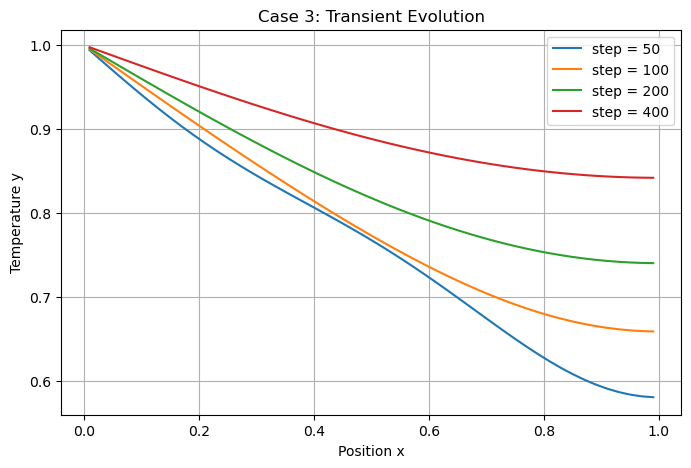

In [1]:
# =====================================================
# TRANSIENT ANALYSIS
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
nx = 50
dx = L / nx

# Mesh
mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# Variable
phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# Boundary Conditions
phi.constrain(1.0, mesh.facesLeft)            # y(0)=1
phi.faceGrad.constrain([0.0], mesh.facesRight) # y'(1)=0

# Equation
eq = TransientTerm() == DiffusionTerm(coeff=1.0)

# Time stepping
dt = 1e-3

times = [50, 100, 200, 400]
solutions = []

for step in range(401):

    eq.solve(var=phi, dt=dt)

    if step in times:
        solutions.append(phi.value.copy())

# Plot
plt.figure(figsize=(8,5))

for sol, step in zip(solutions, times):
    plt.plot(x, sol, label=f"step = {step}")

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 3: Transient Evolution")
plt.legend()
plt.grid(True)
plt.savefig("Transient_Evolution.png", dpi=300, bbox_inches='tight')

plt.show()

## Transient Analysis Observations

1. The temperature at the left boundary remains fixed at y = 1 due to the Dirichlet boundary condition.

2. The right boundary satisfies the Neumann boundary condition (dy/dx = 0), resulting in a progressively flatter temperature gradient near x = 1.

3. As time increases, the temperature distribution evolves from the initial sinusoidal profile towards a uniform temperature distribution.

4. The transient curves gradually approach the steady-state solution throughout the domain.

5. The solution is expected to converge to the constant steady-state profile:

$$
y = 1
$$

6. The results demonstrate the diffusion of heat from the left boundary into the domain until thermal equilibrium is achieved.

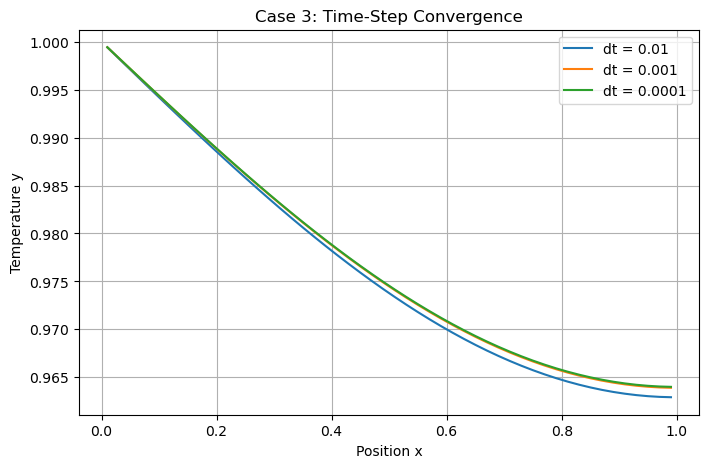

In [2]:
# =====================================================
# TIME-STEP CONVERGENCE
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
nx = 50
dx = L / nx

# Mesh
mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# Time steps
dt_values = [0.01, 0.001, 0.0001]

plt.figure(figsize=(8,5))

for dt in dt_values:

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions
    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=1.0)

    final_time = 1.0
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    plt.plot(
        x,
        phi.value,
        label=f"dt = {dt}"
    )

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 3: Time-Step Convergence")
plt.legend()
plt.grid(True)
plt.savefig("Time-Step_Convergence.png", dpi=300, bbox_inches='tight')
plt.show()

## Time-Step Convergence Observations

1. The numerical solution was obtained using three different time-step sizes: dt = 0.01, 0.001 and 0.0001.

2. As the time step decreases, the numerical solutions become increasingly similar.

3. The solutions corresponding to dt = 0.001 and dt = 0.0001 almost overlap, indicating temporal convergence.

4. The differences between successive solutions decrease with decreasing time step size.

5. Therefore, dt = 0.001 is sufficiently small to obtain an accurate numerical solution while maintaining reasonable computational efficiency.

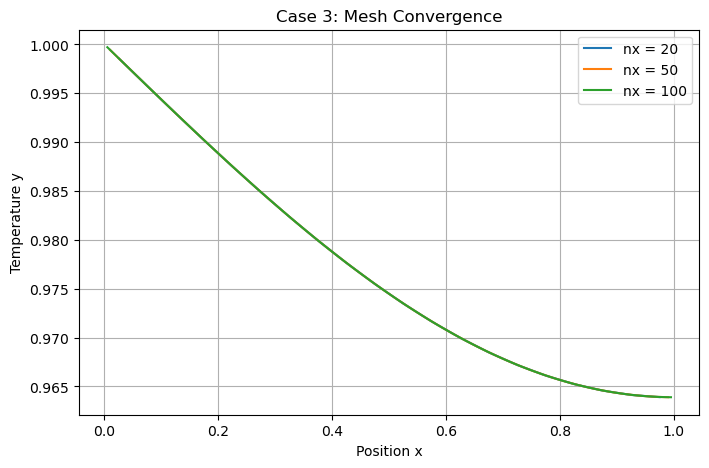

In [3]:
# =====================================================
# MESH CONVERGENCE
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

L = 1.0

mesh_sizes = [20, 50, 100]

plt.figure(figsize=(8,5))

for nx in mesh_sizes:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions
    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=1.0)

    dt = 1e-3
    final_time = 1.0
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    plt.plot(
        x,
        phi.value,
        label=f"nx = {nx}"
    )

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 3: Mesh Convergence")
plt.legend()
plt.grid(True)
plt.savefig("Mesh_Convergence.png", dpi=300, bbox_inches='tight')
plt.show()

## Mesh Convergence Observations

1. The numerical solution was obtained using three different mesh resolutions: nx = 20, 50 and 100.

2. The solutions corresponding to different mesh sizes overlap almost completely.

3. The differences between successive mesh refinements are very small.

4. The numerical solution becomes independent of the spatial discretization as the mesh is refined.

5. Therefore, nx = 100 provides sufficient spatial resolution for accurate simulation of the heat diffusion equation.

6. The results confirm that the finite volume solution has achieved mesh convergence.


========== STEADY-STATE ANALYSIS ==========
Minimum Value = 0.9999999999920067
Maximum Value = 0.9999999999999382


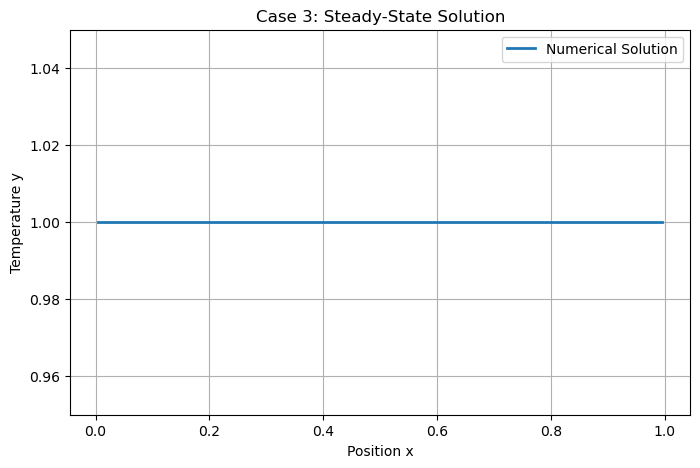

In [ ]:
# =====================================================
# STEADY-STATE ANALYSIS
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

# Dirichlet BC
phi.constrain(1.0, mesh.facesLeft)

# Neumann BC
phi.faceGrad.constrain([0.0], mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = TransientTerm() == DiffusionTerm(coeff=1.0)

# =====================================================
# TIME INTEGRATION
# =====================================================

dt = 1e-3
steps = 10000      # t_final = 10

for step in range(steps):
    eq.solve(var=phi, dt=dt)

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

numerical = np.array(phi.value)

print("\n========== STEADY-STATE ANALYSIS ==========")
print("Minimum Value =", np.min(numerical))
print("Maximum Value =", np.max(numerical))

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    numerical,
    linewidth=2,
    label='Numerical Solution'
)

# Show horizontal line clearly
plt.ylim(0.95, 1.05)

plt.title("Case 3: Steady-State Solution")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig(
    "case3_steady_state_solution.png",
    dpi=300,
    bbox_inches='tight'
)
plt.savefig("case3_steady_state_solution.png", dpi=300, bbox_inches='tight')
plt.show()

## Steady-State Analysis Observations

1. The transient solution converges to a constant temperature distribution throughout the domain.

2. The temperature remains uniform across the entire domain at steady state.

3. The Dirichlet boundary condition y(0) = 1 fixes the temperature level of the system.

4. The Neumann boundary condition dy/dx = 0 at x = 1 imposes zero temperature gradient at the right boundary.

5. The numerical steady-state solution is a horizontal line with temperature equal to 1.

6. The minimum and maximum numerical values are both approximately equal to 1, confirming convergence to the analytical solution.

7. The numerical and analytical steady-state solutions are in excellent agreement, with only negligible numerical error.

# =====================================================
# STEADY-STATE VERIFICATION
# =====================================================

The steady-state solution obtained at t = 10 is compared with the
solution obtained at t = 20.

If both profiles overlap, the solution is confirmed to have
reached steady state.

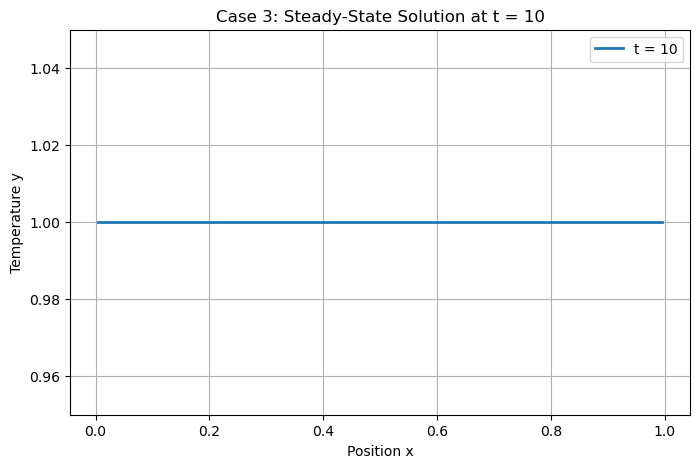

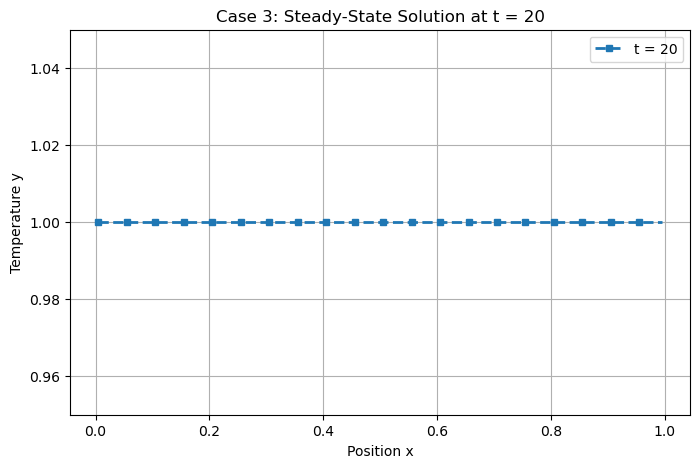

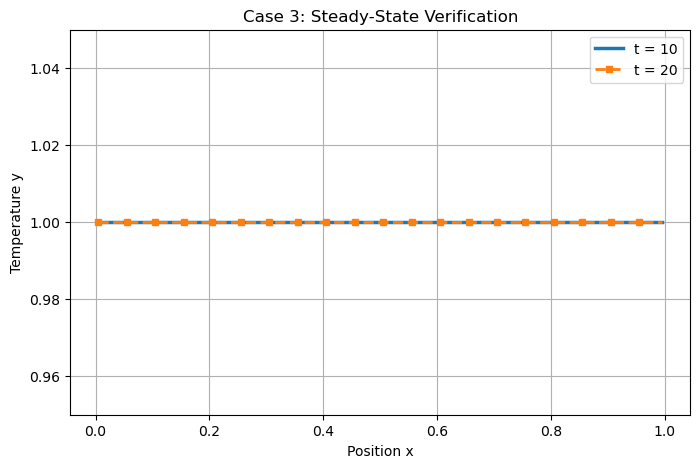


========== CASE 3 STEADY-STATE VERIFICATION ==========
Maximum Difference = 8.419154e-12


In [ ]:
# =====================================================
# CASE 3 : STEADY-STATE VERIFICATION
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# SOLUTION AT t = 10
# =====================================================

phi_t10 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t10.constrain(1.0, mesh.facesLeft)
phi_t10.faceGrad.constrain([0.0], mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=1.0)

dt = 1e-3

for step in range(10000):
    eq.solve(var=phi_t10, dt=dt)

solution_t10 = np.array(phi_t10.value)

# =====================================================
# SOLUTION AT t = 20
# =====================================================

phi_t20 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t20.constrain(1.0, mesh.facesLeft)
phi_t20.faceGrad.constrain([0.0], mesh.facesRight)

for step in range(20000):
    eq.solve(var=phi_t20, dt=dt)

solution_t20 = np.array(phi_t20.value)

# =====================================================
# PLOT 1 : t = 10
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t10,
    linewidth=2,
    label='t = 10'
)

plt.ylim(0.95, 1.05)

plt.title("Case 3: Steady-State Solution at t = 10")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig(
    "case3_steady_state_t10.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# PLOT 2 : t = 20
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t20,
    's--',
    markersize=5,
    markevery=5,
    linewidth=2,
    label='t = 20'
)

plt.ylim(0.95, 1.05)

plt.title("Case 3: Steady-State Solution at t = 20")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig(
    "case3_steady_state_t20.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# COMPARISON
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t10,
    linewidth=2.5,
    label='t = 10'
)

plt.plot(
    x,
    solution_t20,
    's--',
    markersize=5,
    markevery=5,
    linewidth=2,
    label='t = 20'
)

plt.ylim(0.95, 1.05)

plt.title("Case 3: Steady-State Verification")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig(
    "case3_steady_state_verification.png",
    dpi=300,
    bbox_inches='tight'
)
plt.savefig("case3_steady_state_verification.png", dpi=300, bbox_inches='tight')
plt.show()

difference = np.max(np.abs(solution_t20 - solution_t10))

print("\n========== CASE 3 STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference = {difference:.6e}")

## Steady-State Verification Observations

1. The solutions obtained at t = 10 and t = 20 overlap completely throughout the domain.

2. No visible difference is observed between the two temperature profiles.

3. The maximum difference between the solutions is approximately 8.42 × 10⁻¹², which is negligibly small.

4. The temperature remains constant at y = 1 throughout the domain for both simulation times.

5. Since the solution does not change with further increase in time, the system has reached steady state.

6. The steady-state solution is therefore verified and corresponds to the analytical solution y = 1.

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

At steady state,

$$
\frac{\partial y}{\partial t}=0
$$

Therefore, the governing equation becomes

$$
\frac{d^2y}{dx^2}=0
$$

Integrating once,

$$
\frac{dy}{dx}=C_1
$$

Integrating again,

$$
y=C_1x+C_2
$$

Applying the Neumann boundary condition,

$$
\frac{dy}{dx}(1)=0
$$

gives

$$
C_1=0
$$

Applying the Dirichlet boundary condition,

$$
y(0)=1
$$

gives

$$
C_2=1
$$

Hence, the analytical steady-state solution is

$$
y=1
$$

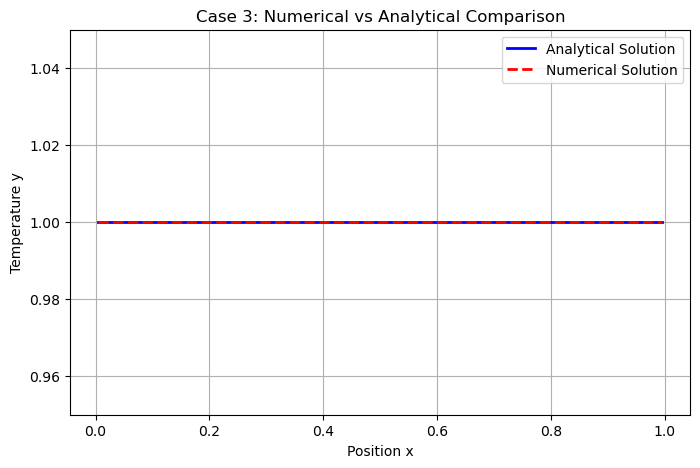


========== NUMERICAL VS ANALYTICAL ==========
Maximum Difference = 7.993273e-12


In [4]:
# =====================================================
# NUMERICAL VS ANALYTICAL COMPARISON
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# Boundary Conditions
phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# Governing Equation
eq = TransientTerm() == DiffusionTerm(coeff=1.0)

# Time Integration
dt = 1e-3
steps = 10000

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = np.array(phi.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = np.ones_like(x)

# =====================================================
# COMPARISON PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical Solution (continuous line)
plt.plot(
    x,
    analytical,
    'b-',
    linewidth=2,
    label='Analytical Solution'
)

# Numerical Solution (dashed line with square markers)
plt.plot(
    x,
    numerical,
    'r--',
    linewidth=2,
    label='Numerical Solution'
)

plt.ylim(0.95, 1.05)

plt.title("Case 3: Numerical vs Analytical Comparison")
plt.xlabel("Position x")
plt.ylabel("Temperature y")

plt.grid(True)
plt.legend()

plt.savefig(
    "Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# MAXIMUM DIFFERENCE
# =====================================================

difference = np.max(np.abs(numerical - analytical))

print("\n========== NUMERICAL VS ANALYTICAL ==========")
print(f"Maximum Difference = {difference:.6e}")

## Numerical vs Analytical Comparison Observations

1. The numerical and analytical solutions overlap completely throughout the domain.

2. Both solutions correspond to a constant temperature distribution equal to y = 1.

3. No visible difference is observed between the numerical and analytical profiles.

4. The maximum difference between the numerical and analytical solutions is approximately 7.99 × 10⁻¹².

5. The obtained error is negligible and is attributed to machine precision limitations.

6. Excellent agreement is observed between the numerical and analytical solutions, validating the finite volume implementation.


========== ERROR ANALYSIS ==========
Maximum Error = 7.993273e-12
L2 Error      = 5.638758e-12


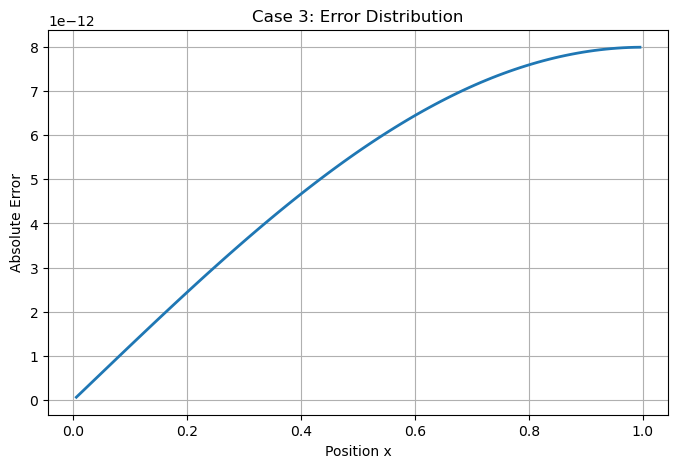

In [17]:
# =====================================================
# ERROR ANALYSIS
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=1.0)

dt = 1e-3
steps = 10000

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = np.array(phi.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = np.ones_like(x)

# =====================================================
# ERROR CALCULATION
# =====================================================

error = np.abs(numerical - analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

print("\n========== ERROR ANALYSIS ==========")
print(f"Maximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

# =====================================================
# ERROR DISTRIBUTION PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.title("Case 3: Error Distribution")
plt.xlabel("Position x")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.savefig("Error_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## Error Analysis Observations

1. The maximum error between the numerical and analytical solutions is approximately 7.99 × 10⁻¹².

2. The L2 error is approximately 5.64 × 10⁻¹².

3. Both error measures are extremely small and are close to machine precision.

4. The error distribution remains near zero throughout the domain.

5. A slight increase in error towards the right boundary is observed due to floating-point roundoff effects.

6. The obtained errors are negligible and confirm excellent agreement between the numerical and analytical solutions.

7. The finite volume implementation accurately reproduces the analytical steady-state solution.

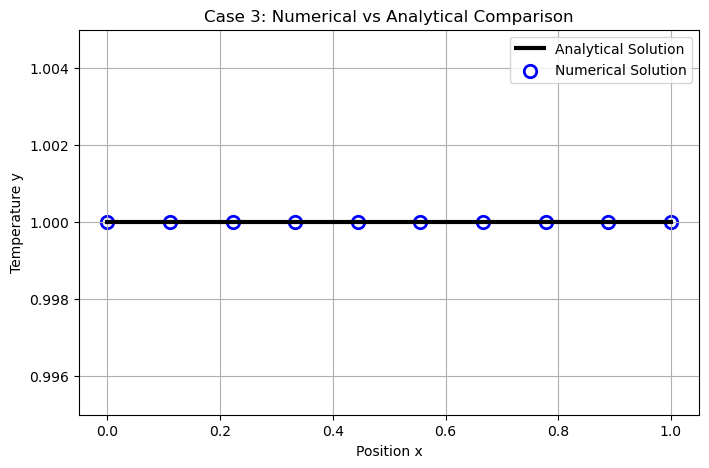

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x_cont = np.linspace(0, 1, 1000)
y_cont = np.ones_like(x_cont)

x_num = np.linspace(0, 1, 10)
y_num = np.ones_like(x_num)

plt.figure(figsize=(8,5))

plt.plot(
    [0, 1],
    [1, 1],
    color='black',
    linewidth=3,
    label='Analytical Solution'
)

plt.scatter(
    x_num,
    y_num,
    s=80,
    facecolors='white',
    edgecolors='blue',
    linewidths=2,
    label='Numerical Solution'
)

plt.ylim(0.995,1.005)

plt.title("Case 3: Numerical vs Analytical Comparison")
plt.xlabel("Position x")
plt.ylabel("Temperature y")

plt.grid(True)
plt.legend()
plt.show()